In [1]:
# load netcdf from OM4 runs

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colorbar import ColorbarBase


/home/abodner/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/new_runs/'

# load FK ideal age data and take mean over last 5 years of JRA cycle
ds_age_FK = xr.open_dataset(BASE+'BFF11/ocean_annual_z.2018-2022.ann-001.nc')
age_FK = ds_age_FK.agessc.mean('time')

# load BD ideal age data and take mean over last 5 years of JRA cycle
ds_age_BD = xr.open_dataset(BASE+'BOD23/ocean_annual_z.2018-2022.ann-001.nc')
age_BD = ds_age_BD.agessc.mean('time')



# load static file
#ds_stat = xr.open_dataset(BASE+'ocean_annual_z.static.nc')

In [3]:
### BLOM ###
# path to dataset
PATH_BLOM = '/orcd/data/abodner/001/blom_output/'
# load BFF11 data 
BLOM_AGE_BFF11 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner01_ideal_age.nc')  

# load BOD23 data tuned
BLOM_AGE_BOD23 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner03_ideal_age.nc')  

#load grid
BLOM_grid = xr.open_dataset(PATH_BLOM+'grid_tnx1v4_20170622.nc')  


In [4]:
### CESM ###
# path to dataset
PATH_CESM = '/orcd/data/abodner/001/cesm_output/'

# load BFF11 data 
CESM_AGE_BFF11_100m = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_age_100m.nc')
CESM_AGE_BFF11_1750m = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_age_1750m.nc') 


# load BOD23 data tuned 
CESM_AGE_BOD23_100m = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_age_100m.nc')
CESM_AGE_BOD23_1750m = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_age_1750m.nc') 



In [5]:
def enable_global(tlon,tlat,data):
  """Fix the data in such a way that it can to be plotted on a global projection on its native grid"""
  tlon = np.where(np.greater_equal(tlon,min(tlon[:,0])),tlon-360,tlon)
  tlon=tlon+abs(np.max(tlon)); tlon=tlon+360
  # stack grids side-by-side (in longitiudinal direction), so
  # any range of longitudes may be plotted on a world map.
  tlon = np.concatenate((tlon,tlon+360),1)
  tlat = np.concatenate((tlat,tlat),1)
  data = np.concatenate((data,data),1)
  tlon = tlon-360.
  tlon -= 110.0
  return tlon, tlat, data



## plot MLD and ideal age 

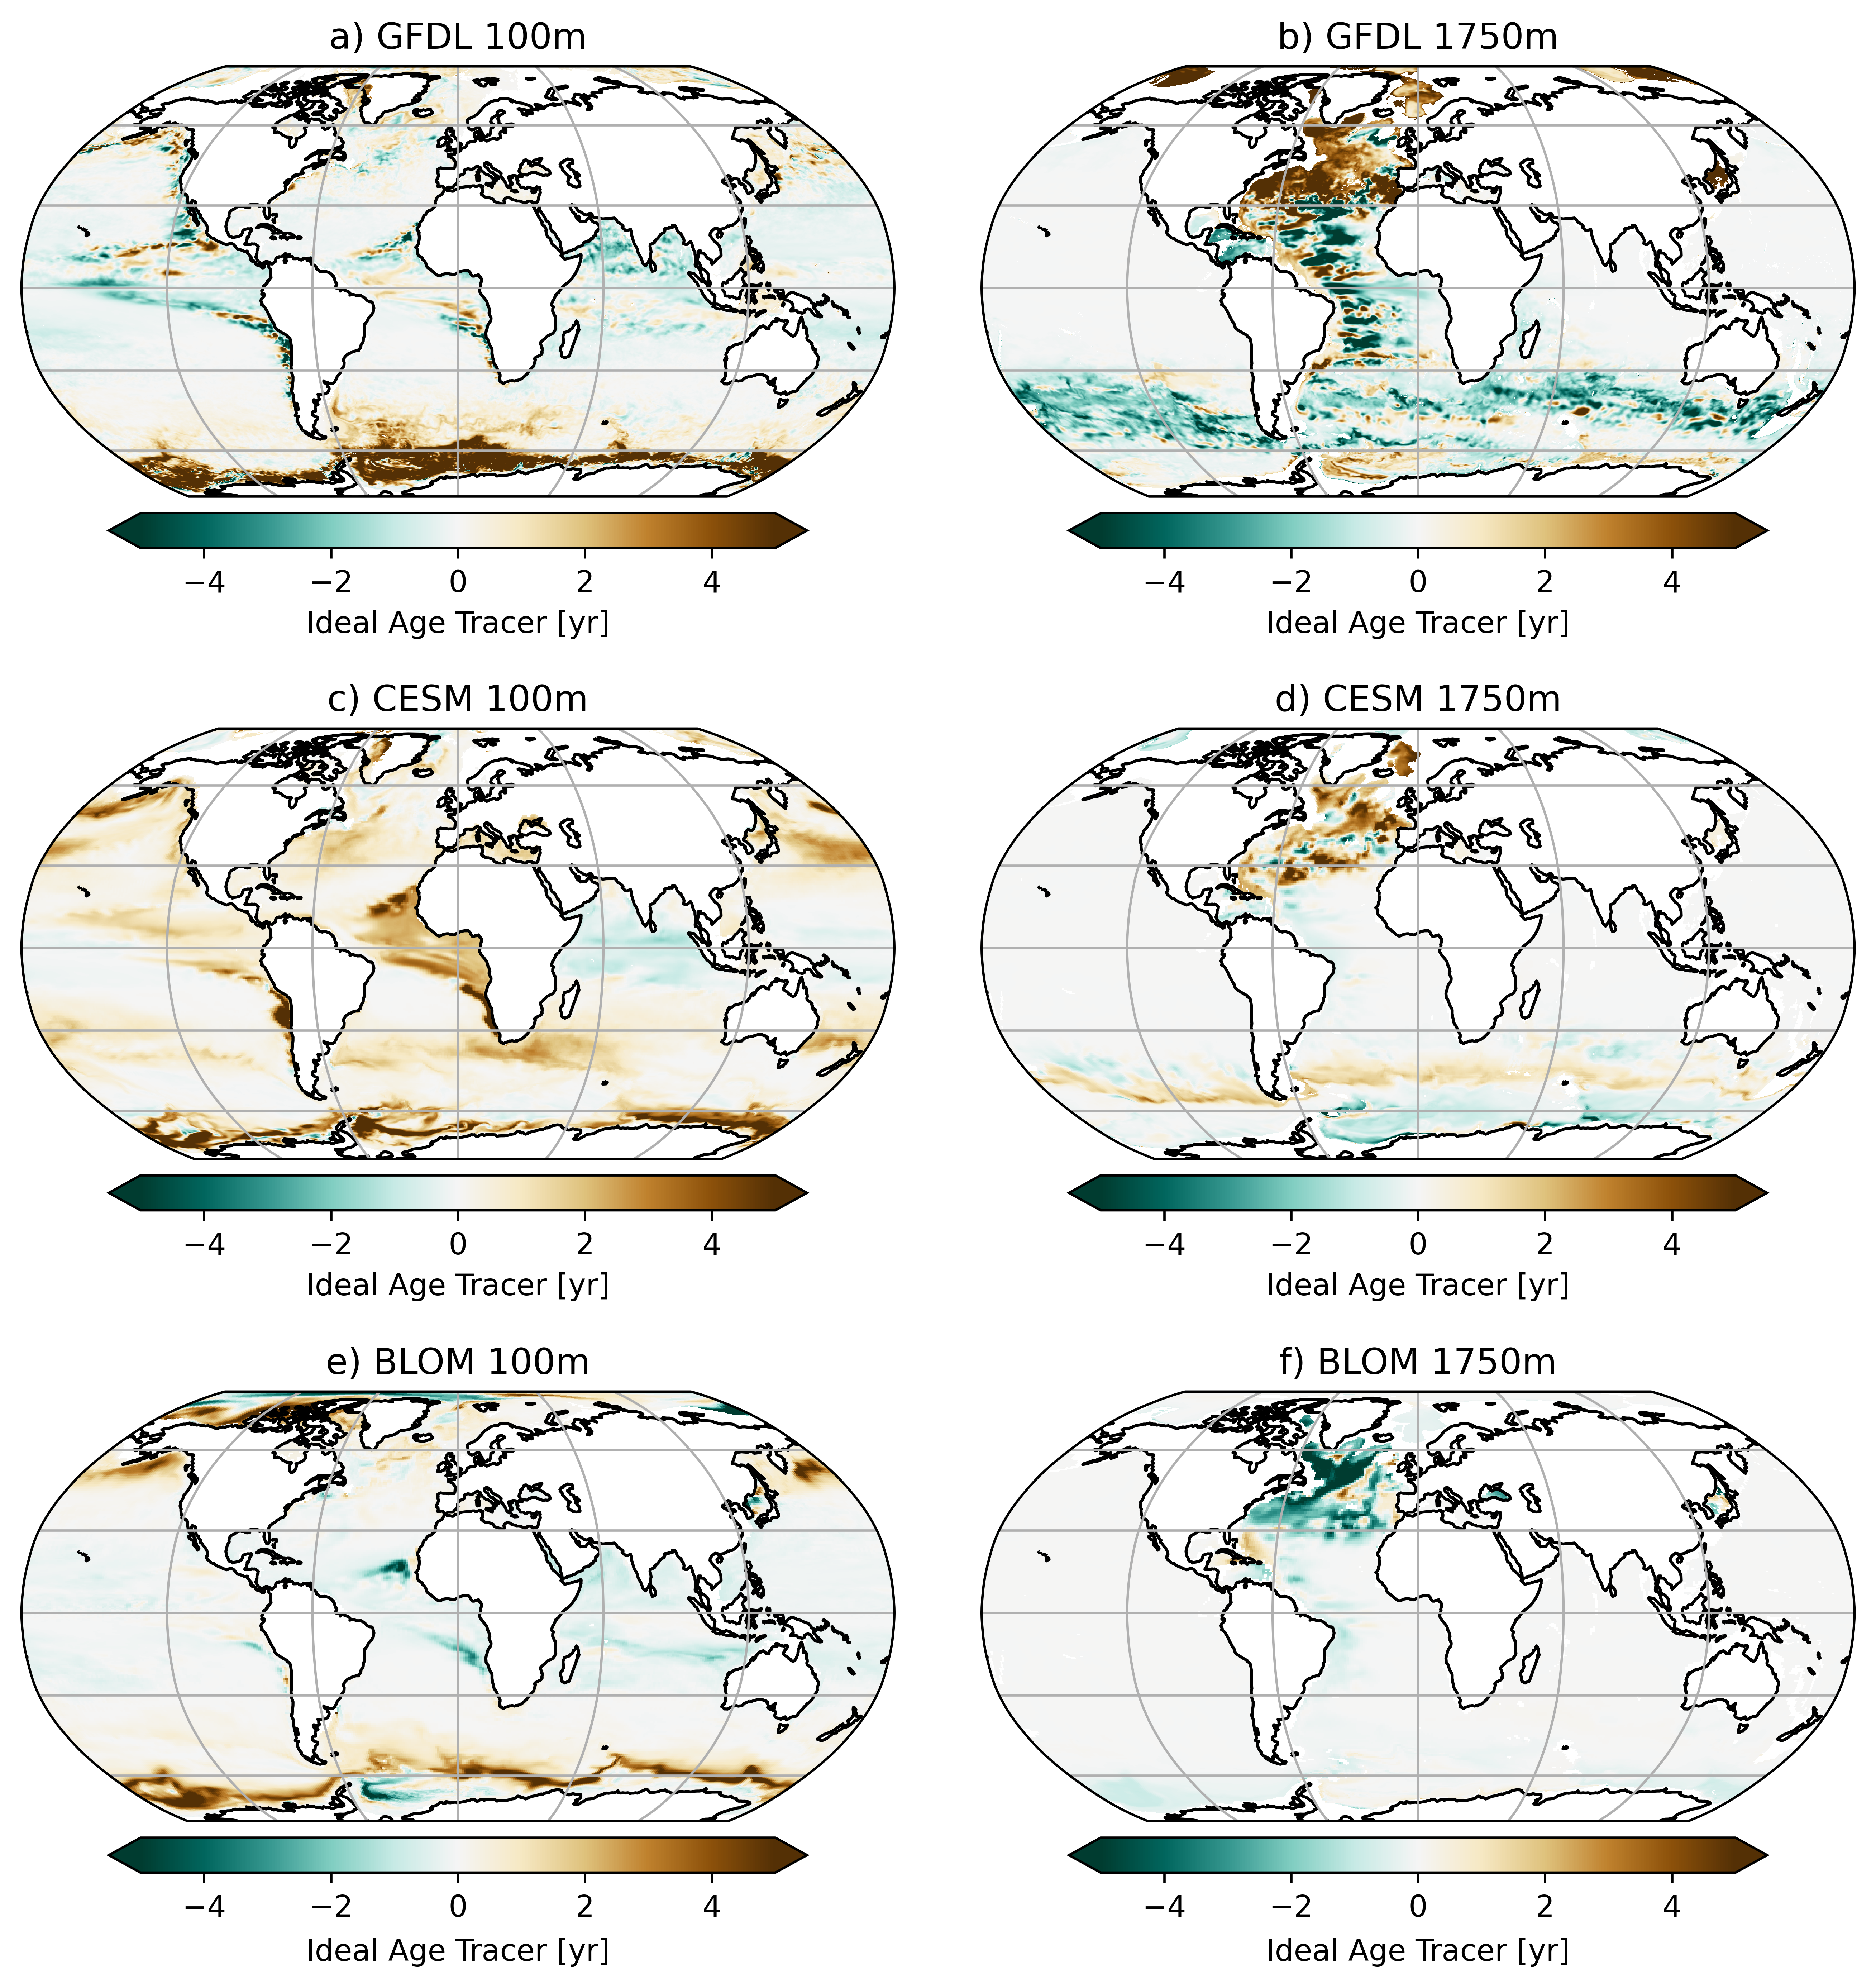

In [6]:
# create a figure
#fig = plt.figure()
fig, ax = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        figsize=(11,13), dpi=600)


ax=ax.flatten()

cbar_lim = 5  

# ideal age BD minus FK - depth (100m) GFDL
i_ax = 0

(age_BD.isel(z_l=6) - age_FK.isel(z_l=6) ).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('a) GFDL 100m')


# ideal age BD minus FK - depth (1750m) GFDL
i_ax = 1
(age_BD.isel(z_l=24) - age_FK.isel(z_l=24) ).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)

ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('b) GFDL 1750m')



## CESM plots
# ideal age BD minus FK - depth (100m) CESM
i_ax = 2

(CESM_AGE_BOD23_100m.agessc - CESM_AGE_BFF11_100m.agessc).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('c) CESM 100m')


# ideal age BD minus FK - depth (1750m) CESM
i_ax = 3
((CESM_AGE_BOD23_1750m.agessc - CESM_AGE_BFF11_1750m.agessc)).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)

ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('d) CESM 1750m')




# ideal age BD minus FK - depth (100m) BLOM
i_ax = 4

tlon, tlat, data = enable_global(BLOM_grid.plon, BLOM_grid.plat,
                                 (BLOM_AGE_BOD23.ideal_age_100m - BLOM_AGE_BFF11.ideal_age_100m).rename('Ideal Age Tracer [yr]'))
im = ax[i_ax].pcolormesh(tlon, tlat, data,
                    transform=ccrs.PlateCarree(),  
                    vmin=-cbar_lim,
                    vmax=cbar_lim,          
                    cmap="BrBG_r")
              
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('e) BLOM 100m')
cbar = plt.colorbar(im, ax=ax[i_ax],orientation= 'horizontal',pad= 0.02, shrink=0.8,extend='both')
cbar.set_label('Ideal Age Tracer [yr]', labelpad=5)

# ideal age BD minus FK - depth (1750m) BLOM
i_ax = 5
tlon, tlat, data = enable_global(BLOM_grid.plon, BLOM_grid.plat,
                                 (BLOM_AGE_BOD23.ideal_age_1750m - BLOM_AGE_BFF11.ideal_age_1750m).rename('Ideal Age Tracer [yr]'))
im = ax[i_ax].pcolormesh(tlon, tlat, data,
                    transform=ccrs.PlateCarree(),  
                    vmin=-cbar_lim,
                    vmax=cbar_lim,          
                    cmap="BrBG_r")
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('f) BLOM 1750m')
cbar = plt.colorbar(im, ax=ax[i_ax],orientation= 'horizontal',pad= 0.02, shrink=0.8,extend='both')
cbar.set_label('Ideal Age Tracer [yr]', labelpad=5)

plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(wspace=0.1, hspace=-0.2)

# save figure
#plt.savefig('./figures/ideal_age_all_models')


In [12]:
# compute_ideal_age_metrics.py
import numpy as np
import xarray as xr
import pandas as pd

# ======================
# Helpers (same as in MLD script)
# ======================
def _find_lat(da, candidates=("lat","latitude","yh","y","TLAT","plat","qlat")):
    for name in candidates:
        if name in da.coords:
            return da[name]
    return None

def region_mask(lat, lat_min=None, lat_max=None):
    m = xr.ones_like(lat, dtype=bool)
    if lat_min is not None: m = m & (lat >= lat_min)
    if lat_max is not None: m = m & (lat <= lat_max)
    return m

def area_weighted_mean(da: xr.DataArray, lat: xr.DataArray|None=None,
                       lat_min=None, lat_max=None) -> float:
    if lat is None:
        lat = _find_lat(da)
    if lat is None:
        raise KeyError("Latitude not found; pass lat= explicitly.")
    m = region_mask(lat, lat_min, lat_max)
    w = np.cos(np.deg2rad(lat))
    out = da.where(m).weighted(w).mean(skipna=True)
    return out.item() if hasattr(out, "item") else float(out)

def pct_change(new: float, baseline: float) -> float:
    return 100.0 * (new - baseline) / baseline

# ======================
# INPUTS (edit to your variables)
# ======================
# GFDL ideal age fields (DataArray) with dim z_l:
# age_BD.isel(z_l=6/24), age_FK.isel(z_l=6/24)

# CESM ideal age fields (DataArray) at fixed depths:
# CESM_AGE_BOD23_100m.agessc, CESM_AGE_BFF11_100m.agessc, CESM_AGE_BOD23_1750m.agessc, CESM_AGE_BFF11_1750m.agessc

# BLOM ideal age fields (DataArray) and grid lat:
# BLOM_AGE_BOD23.ideal_age_100m / _1750m, BLOM_AGE_BFF11.ideal_age_100m / _1750m
# BLOM_grid.qlat  (pass as lat= ...)

def compute_all():
    rows = []
    # Regions
    so = dict(lat_min=None, lat_max=-50.0)  # Southern Ocean: lat < -40
    na = dict(lat_min=35.0, lat_max=None)   # North Atlantic: lat > 30

    # ---- GFDL (z levels: 6≈100m, 24≈1750m) ----
    for depth_name, iz in [("100m", 6), ("1750m", 24)]:
        bod = area_weighted_mean(age_BD.isel(z_l=iz), **so)
        bff = area_weighted_mean(age_FK.isel(z_l=iz), **so)
        rows.append(("GFDL", depth_name, "Southern Ocean", pct_change(bod, bff)))

        bod = area_weighted_mean(age_BD.isel(z_l=iz), **na)
        bff = area_weighted_mean(age_FK.isel(z_l=iz), **na)
        rows.append(("GFDL", depth_name, "North Atlantic", pct_change(bod, bff)))

    # ---- CESM ----
    for depth_name, da_bod, da_bff in [
        ("100m",  CESM_AGE_BOD23_100m.agessc,  CESM_AGE_BFF11_100m.agessc),
        ("1750m", CESM_AGE_BOD23_1750m.agessc, CESM_AGE_BFF11_1750m.agessc),
    ]:
        rows.append(("CESM", depth_name, "Southern Ocean",
                     pct_change(area_weighted_mean(da_bod, **so),
                                area_weighted_mean(da_bff, **so))))
        rows.append(("CESM", depth_name, "North Atlantic",
                     pct_change(area_weighted_mean(da_bod, **na),
                                area_weighted_mean(da_bff, **na))))

    # ---- BLOM (pass qlat explicitly) ----
    for depth_name, da_bod, da_bff in [
        ("100m",  BLOM_AGE_BOD23.ideal_age_100m,  BLOM_AGE_BFF11.ideal_age_100m),
        ("1750m", BLOM_AGE_BOD23.ideal_age_1750m, BLOM_AGE_BFF11.ideal_age_1750m),
    ]:
        rows.append(("BLOM", depth_name, "Southern Ocean",
                     pct_change(area_weighted_mean(da_bod, lat=BLOM_grid.qlat, **so),
                                area_weighted_mean(da_bff, lat=BLOM_grid.qlat, **so))))
        rows.append(("BLOM", depth_name, "North Atlantic",
                     pct_change(area_weighted_mean(da_bod, lat=BLOM_grid.qlat, **na),
                                area_weighted_mean(da_bff, lat=BLOM_grid.qlat, **na))))

    df = pd.DataFrame(rows, columns=["Model","Depth","Region","PercentDiff(BOD23 vs BFF11)"])
    return df

if __name__ == "__main__":
    df = compute_all()
    print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    df.to_csv("ideal_age_metrics.csv", index=False)
    print("\nSaved: ideal_age_metrics.csv")


Model Depth         Region  PercentDiff(BOD23 vs BFF11)
 GFDL  100m Southern Ocean                        39.11
 GFDL  100m North Atlantic                         5.30
 GFDL 1750m Southern Ocean                        -0.25
 GFDL 1750m North Atlantic                         1.94
 CESM  100m Southern Ocean                        35.74
 CESM  100m North Atlantic                        28.71
 CESM 1750m Southern Ocean                        -0.35
 CESM 1750m North Atlantic                         1.24
 BLOM  100m Southern Ocean                         9.12
 BLOM  100m North Atlantic                        13.33
 BLOM 1750m Southern Ocean                        -0.23
 BLOM 1750m North Atlantic                        -1.75

Saved: ideal_age_metrics.csv


In [15]:
import numpy as np
import xarray as xr

# ---------- helpers ----------
def _find_coord(da, candidates):
    for name in candidates:
        if name in da.coords:
            return da[name]
    return None

def _find_lat(da): return _find_coord(da, ("lat","latitude","yh","y","TLAT","plat","qlat"))
def _find_lon(da): return _find_coord(da, ("lon","longitude","xh","x","TLONG","plon","qlon"))

def _to_minus180_180(lon):
    """Normalize longitudes into [-180, 180]"""
    return ((lon + 180) % 360) - 180

def _lon_mask(lon, lon_min=None, lon_max=None):
    """Boolean mask for lon range on [-180,180], supports dateline wrap."""
    if lon_min is None and lon_max is None:
        return xr.ones_like(lon, dtype=bool)
    L = _to_minus180_180(lon)
    a = _to_minus180_180(lon_min) if lon_min is not None else -180.0
    b = _to_minus180_180(lon_max) if lon_max is not None else  180.0
    if a <= b:
        return (L >= a) & (L <= b)
    else:
        # wrapped range, e.g. [170, -160] (i.e., 170..180 ∪ -180..-160)
        return (L >= a) | (L <= b)

def area_weighted_mean_region(da: xr.DataArray,
                              lat: xr.DataArray|None=None,
                              lon: xr.DataArray|None=None,
                              lat_min=None, lat_max=None,
                              lon_min=None, lon_max=None) -> float:
    """Cos(phi)-weighted mean over an optional lat/lon box."""
    if lat is None: lat = _find_lat(da)
    if lon is None: lon = _find_lon(da)
    if lat is None or lon is None:
        raise KeyError("lat/lon not found. Pass `lat=` and `lon=` explicitly if on a separate grid object.")

    # masks
    m = xr.ones_like(lat, dtype=bool)
    if lat_min is not None: m = m & (lat >= lat_min)
    if lat_max is not None: m = m & (lat <= lat_max)
    m = m & _lon_mask(lon, lon_min, lon_max)

    # weights
    w = np.cos(np.deg2rad(lat))
    out = da.where(m).weighted(w).mean(skipna=True)
    return out.item() if hasattr(out, "item") else float(out)

def pct_change(new, baseline):
    return 100.0 * (new - baseline) / baseline  # % (BOD23 vs BFF11, etc.)

# ---------- North Atlantic box (example) ----------
# Common NA box: lat > 30°, lon in [-80, 10] (adjust as you like)
NA = dict(lat_min=35.0, lat_max=None, lon_min=-80.0, lon_max=10.0)

# ===== GFDL (z_l index: 6≈100m, 24≈1750m) =====
NA_BOD23_100 = area_weighted_mean_region(age_BD.isel(z_l=6),  **NA)
NA_BFF11_100 = area_weighted_mean_region(age_FK.isel(z_l=6),  **NA)
NA_pct_age_GFDL_100 = pct_change(NA_BOD23_100, NA_BFF11_100)

NA_BOD23_1750 = area_weighted_mean_region(age_BD.isel(z_l=24), **NA)
NA_BFF11_1750 = area_weighted_mean_region(age_FK.isel(z_l=24), **NA)
NA_pct_age_GFDL_1750 = pct_change(NA_BOD23_1750, NA_BFF11_1750)

print(f"GFDL North Atlantic (lon -80..10, lat >30): "
      f"100m {NA_pct_age_GFDL_100:.2f}%, 1750m {NA_pct_age_GFDL_1750:.2f}% (BOD23 vs BFF11)")

# ===== CESM (fixed-depth DataArrays) =====
NA_pct_age_CESM_100 = pct_change(
    area_weighted_mean_region(CESM_AGE_BOD23_100m.agessc, **NA),
    area_weighted_mean_region(CESM_AGE_BFF11_100m.agessc, **NA),
)
NA_pct_age_CESM_1750 = pct_change(
    area_weighted_mean_region(CESM_AGE_BOD23_1750m.agessc, **NA),
    area_weighted_mean_region(CESM_AGE_BFF11_1750m.agessc, **NA),
)
print(f"CESM North Atlantic: 100m {NA_pct_age_CESM_100:.2f}%, 1750m {NA_pct_age_CESM_1750:.2f}%")

# ===== BLOM (pass curvilinear lat/lon explicitly; use q-grid to match fields) =====
# If your ideal-age fields are on the q-grid:
NA_pct_age_BLOM_100 = pct_change(
    area_weighted_mean_region(BLOM_AGE_BOD23.ideal_age_100m,  lat=BLOM_grid.qlat, lon=BLOM_grid.qlon, **NA),
    area_weighted_mean_region(BLOM_AGE_BFF11.ideal_age_100m,  lat=BLOM_grid.qlat, lon=BLOM_grid.qlon, **NA),
)
NA_pct_age_BLOM_1750 = pct_change(
    area_weighted_mean_region(BLOM_AGE_BOD23.ideal_age_1750m, lat=BLOM_grid.qlat, lon=BLOM_grid.qlon, **NA),
    area_weighted_mean_region(BLOM_AGE_BFF11.ideal_age_1750m, lat=BLOM_grid.qlat, lon=BLOM_grid.qlon, **NA),
)
print(f"BLOM North Atlantic: 100m {NA_pct_age_BLOM_100:.2f}%, 1750m {NA_pct_age_BLOM_1750:.2f}%")


GFDL North Atlantic (lon -80..10, lat >30): 100m 6.29%, 1750m 6.36% (BOD23 vs BFF11)
CESM North Atlantic: 100m 33.10%, 1750m 5.25%
BLOM North Atlantic: 100m 7.10%, 1750m -6.15%


In [7]:
import numpy as np
import xarray as xr

def _find_lat(da, candidates=("lat","latitude","yh","y","TLAT","plat","qlat")):
    for name in candidates:
        if name in da.coords:
            return da[name]
    return None

def global_mean(da: xr.DataArray, lat: xr.DataArray | None = None):
    """
    Area-weighted (cos φ) global mean of `da`.
    `lat` can be None (auto-detect), a 1D latitude coord, or a 2D latitude field.
    """
    if lat is None:
        lat = _find_lat(da)
    if lat is None:
        raise KeyError("No latitude coord found. Pass `lat=` explicitly.")

    weights = np.cos(np.deg2rad(lat))                # 1D or 2D; xarray will broadcast
    wmean = da.weighted(weights).mean(skipna=True)   # weight across all overlapping dims
    return wmean.item() if hasattr(wmean, "item") else float(wmean)


In [9]:
# ---- GFDL ----
mean_GFDL_BD_100m  = global_mean(age_BD.isel(z_l=6))
mean_GFDL_FK_100m  = global_mean(age_FK.isel(z_l=6))
mean_GFDL_BD_1750m = global_mean(age_BD.isel(z_l=24))
mean_GFDL_FK_1750m = global_mean(age_FK.isel(z_l=24))

# ---- CESM ----
mean_CESM_BOD23_100m  = global_mean(CESM_AGE_BOD23_100m.agessc)
mean_CESM_BFF11_100m  = global_mean(CESM_AGE_BFF11_100m.agessc)
mean_CESM_BOD23_1750m = global_mean(CESM_AGE_BOD23_1750m.agessc)
mean_CESM_BFF11_1750m = global_mean(CESM_AGE_BFF11_1750m.agessc)

# ---- BLOM (pass lat explicitly) ----
mean_BLOM_BOD23_100m  = global_mean(BLOM_AGE_BOD23.ideal_age_100m,  lat=BLOM_grid.qlat)
mean_BLOM_BFF11_100m  = global_mean(BLOM_AGE_BFF11.ideal_age_100m,  lat=BLOM_grid.qlat)
mean_BLOM_BOD23_1750m = global_mean(BLOM_AGE_BOD23.ideal_age_1750m, lat=BLOM_grid.qlat)
mean_BLOM_BFF11_1750m = global_mean(BLOM_AGE_BFF11.ideal_age_1750m, lat=BLOM_grid.qlat)

# ---- Collect results ----
global_means = {
    # GFDL
    "GFDL BD 100m":  mean_GFDL_BD_100m,
    "GFDL FK 100m":  mean_GFDL_FK_100m,
    "GFDL BD 1750m": mean_GFDL_BD_1750m,
    "GFDL FK 1750m": mean_GFDL_FK_1750m,

    # CESM
    "CESM BOD23 100m":  mean_CESM_BOD23_100m,
    "CESM BFF11 100m":  mean_CESM_BFF11_100m,
    "CESM BOD23 1750m": mean_CESM_BOD23_1750m,
    "CESM BFF11 1750m": mean_CESM_BFF11_1750m,

    # BLOM
    "BLOM BOD23 100m":  mean_BLOM_BOD23_100m,
    "BLOM BFF11 100m":  mean_BLOM_BFF11_100m,
    "BLOM BOD23 1750m": mean_BLOM_BOD23_1750m,
    "BLOM BFF11 1750m": mean_BLOM_BFF11_1750m,
}

# ---- Print neatly ----
print("\nGlobal mean Ideal Age (years):")
for k, v in global_means.items():
    print(f"{k:18s}: {v:.3f}")



Global mean Ideal Age (years):
GFDL BD 100m      : 7.840
GFDL FK 100m      : 7.283
GFDL BD 1750m     : 114.377
GFDL FK 1750m     : 114.499
CESM BOD23 100m   : 5.791
CESM BFF11 100m   : 5.156
CESM BOD23 1750m  : 55.680
CESM BFF11 1750m  : 55.610
BLOM BOD23 100m   : 8.323
BLOM BFF11 100m   : 8.229
BLOM BOD23 1750m  : 58.003
BLOM BFF11 1750m  : 58.113


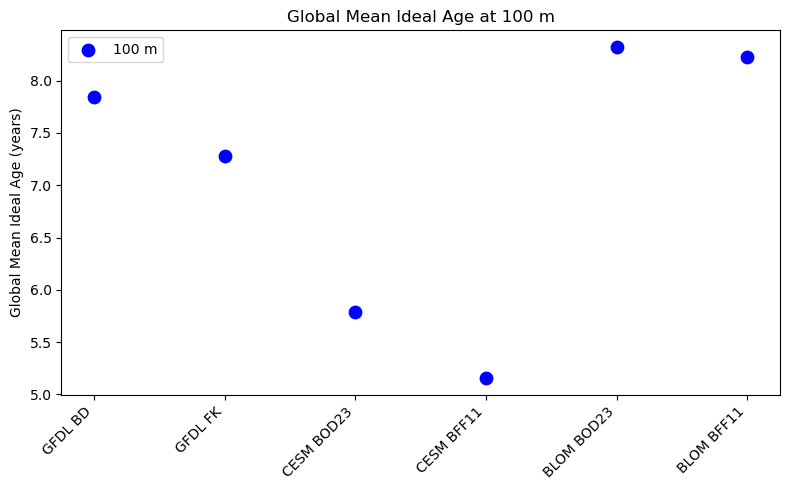

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Collect into arrays ----
labels = ["GFDL BD", "GFDL FK", 
          "CESM BOD23", "CESM BFF11",
          "BLOM BOD23", "BLOM BFF11"]

# order must match labels
means_100m = [
    mean_GFDL_BD_100m, mean_GFDL_FK_100m,
    mean_CESM_BOD23_100m, mean_CESM_BFF11_100m,
    mean_BLOM_BOD23_100m, mean_BLOM_BFF11_100m,
]

means_1750m = [
    mean_GFDL_BD_1750m, mean_GFDL_FK_1750m,
    mean_CESM_BOD23_1750m, mean_CESM_BFF11_1750m,
    mean_BLOM_BOD23_1750m, mean_BLOM_BFF11_1750m,
]

x = np.arange(len(labels))

# ---- Plot ----
plt.figure(figsize=(8,5))

plt.scatter(x, means_100m, marker='o', s=80, c='blue', label='100 m')
#plt.scatter(x, means_1750m, marker='s', s=80, c='red', label='1750 m')

plt.xticks(ticks=x, labels=labels, rotation=45, ha="right")
plt.ylabel("Global Mean Ideal Age (years)")
plt.title("Global Mean Ideal Age at 100 m")
plt.legend()

plt.tight_layout()
plt.savefig('./figures/GlobalMeans_IdealAge_100m.png', dpi=600, bbox_inches='tight')
plt.show()


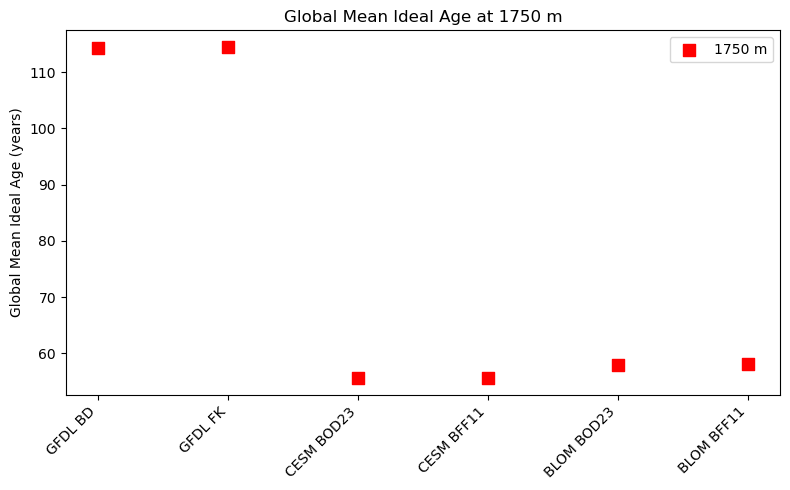

In [13]:
# ---- Plot ----
plt.figure(figsize=(8,5))

#plt.scatter(x, means_100m, marker='o', s=80, c='blue', label='100 m')
plt.scatter(x, means_1750m, marker='s', s=80, c='red', label='1750 m')

plt.xticks(ticks=x, labels=labels, rotation=45, ha="right")
plt.ylabel("Global Mean Ideal Age (years)")
plt.title("Global Mean Ideal Age at 1750 m")
plt.legend()

plt.tight_layout()
plt.savefig('./figures/GlobalMeans_IdealAge_1750m.png', dpi=600, bbox_inches='tight')
plt.show()
